In [2]:
import numpy as np

# Input: [study_hours, sleep_hours]; Output: marks (percentage)
X = np.array(([2, 9], [1, 5], [3, 6]), dtype=float)
y = np.array(([92], [86], [89]), dtype=float)

# Normalize features and target to [0, 1] range
X = X / np.amax(X, axis=0)
y = y / 100

def sigmoid(x):
    """Activation function: squashes values to (0, 1)."""
    return 1 / (1 + np.exp(-x))

def derivatives_sigmoid(x):
    """Derivative of sigmoid for backpropagation."""
    return x * (1 - x)

# Hyperparameters
epoch = 7000          # Training iterations
lr = 0.1              # Learning rate
inputlayer_neurons = 2
hiddenlayer_neurons = 3
output_neurons = 1

# Initialize weights and biases randomly
wh = np.random.uniform(size=(inputlayer_neurons, hiddenlayer_neurons))
bh = np.random.uniform(size=(1, hiddenlayer_neurons))
wout = np.random.uniform(size=(hiddenlayer_neurons, output_neurons))
bout = np.random.uniform(size=(1, output_neurons))

for i in range(epoch):
    # --- Forward propagation ---
    hinp1 = np.dot(X, wh)
    hinp = hinp1 + bh
    hlayer_act = sigmoid(hinp)

    outinp1 = np.dot(hlayer_act, wout)
    outinp = outinp1 + bout
    output = sigmoid(outinp)

    # --- Backpropagation ---
    EO = y - output                              # Output error
    outgrad = derivatives_sigmoid(output)
    d_output = EO * outgrad

    EH = d_output.dot(wout.T)                    # Error at hidden layer
    hiddengrad = derivatives_sigmoid(hlayer_act)
    d_hiddenlayer = EH * hiddengrad

    # --- Weight & bias updates (gradient descent) ---
    wout += hlayer_act.T.dot(d_output) * lr
    bout += np.sum(d_output, axis=0, keepdims=True) * lr
    wh += X.T.dot(d_hiddenlayer) * lr
    bh += np.sum(d_hiddenlayer, axis=0, keepdims=True) * lr

    # Print progress every 1000 epochs
    if i % 1000 == 0:
        loss = np.mean(np.square(y - output))
        print(f"Epoch {i}/{epoch}, Loss: {loss}")
        print("Input:\n", X)
        print("Actual Output:\n", y)
        print("Predicted Output:\n", output)
        print("-" * 50)

Epoch 0/7000, Loss: 0.03544700562484289
Input:
 [[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
 [[0.92]
 [0.86]
 [0.89]]
Predicted Output:
 [[0.70513775]
 [0.69846092]
 [0.70539135]]
--------------------------------------------------
Epoch 1000/7000, Loss: 0.0004003636179000598
Input:
 [[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
 [[0.92]
 [0.86]
 [0.89]]
Predicted Output:
 [[0.89325902]
 [0.88154253]
 [0.89468298]]
--------------------------------------------------
Epoch 2000/7000, Loss: 0.00039648392293648423
Input:
 [[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
 [[0.92]
 [0.86]
 [0.89]]
Predicted Output:
 [[0.89335578]
 [0.88137246]
 [0.89477025]]
--------------------------------------------------
Epoch 3000/7000, Loss: 0.0003925804298378558
Input:
 [[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
 [[0.92]
 [

In [3]:
import numpy as np

def step_function(x):
    """Returns 1 if x >= 0, else 0 (Heaviside step)."""
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size)   # Initialize weights to zero
        self.bias = 0
        self.learning_rate = learning_rate

    def predict(self, inputs):
        """Compute weighted sum + step activation."""
        summation = np.dot(inputs, self.weights) + self.bias
        return step_function(summation)

    def train(self, X, y, epochs=10):
        """Perceptron learning rule for each sample."""
        for epoch in range(epochs):
            for i in range(len(X)):
                prediction = self.predict(X[i])
                error = y[i] - prediction
                # Update weights and bias proportional to error
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
            print(f"Epoch {epoch+1}: Weights: {self.weights}, Bias: {self.bias}")
        print(f"\nFinal Weights after training: {self.weights}")
        print(f"\nFinal bias after training: {self.bias}")

# AND gate truth table
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# OR gate truth table
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

# Train AND perceptron
perceptron_and = Perceptron(input_size=2)
print("Training perceptron for AND gate")
perceptron_and.train(X_and, y_and)

# Train OR perceptron
perceptron_or = Perceptron(input_size=2)
print("Training perceptron for OR gate")
perceptron_or.train(X_or, y_or)

# Test both gates
print("\nTesting predictions")
test_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

print("\nPredictions for AND gate")
for test in test_inputs:
    print(f"Input: {test} -> Prediction: {perceptron_and.predict(test)}")

print("\nPredictions for OR gate")
for test in test_inputs:
    print(f"Input: {test} -> Prediction: {perceptron_or.predict(test)}")

Training perceptron for AND gate
Epoch 1: Weights: [0.1 0.1], Bias: 0.0
Epoch 2: Weights: [0.2 0.1], Bias: -0.1
Epoch 3: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 4: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 5: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 6: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 7: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 8: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 9: Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 10: Weights: [0.2 0.1], Bias: -0.20000000000000004

Final Weights after training: [0.2 0.1]

Final bias after training: -0.20000000000000004
Training perceptron for OR gate
Epoch 1: Weights: [0.  0.1], Bias: 0.0
Epoch 2: Weights: [0.1 0.1], Bias: 0.0
Epoch 3: Weights: [0.1 0.1], Bias: -0.1
Epoch 4: Weights: [0.1 0.1], Bias: -0.1
Epoch 5: Weights: [0.1 0.1], Bias: -0.1
Epoch 6: Weights: [0.1 0.1], Bias: -0.1
Epoch 7: Weights: [0.1 0.1], Bias: -0.1
Epoch 8: Weights: [0.1 0.1], Bias: -0.1

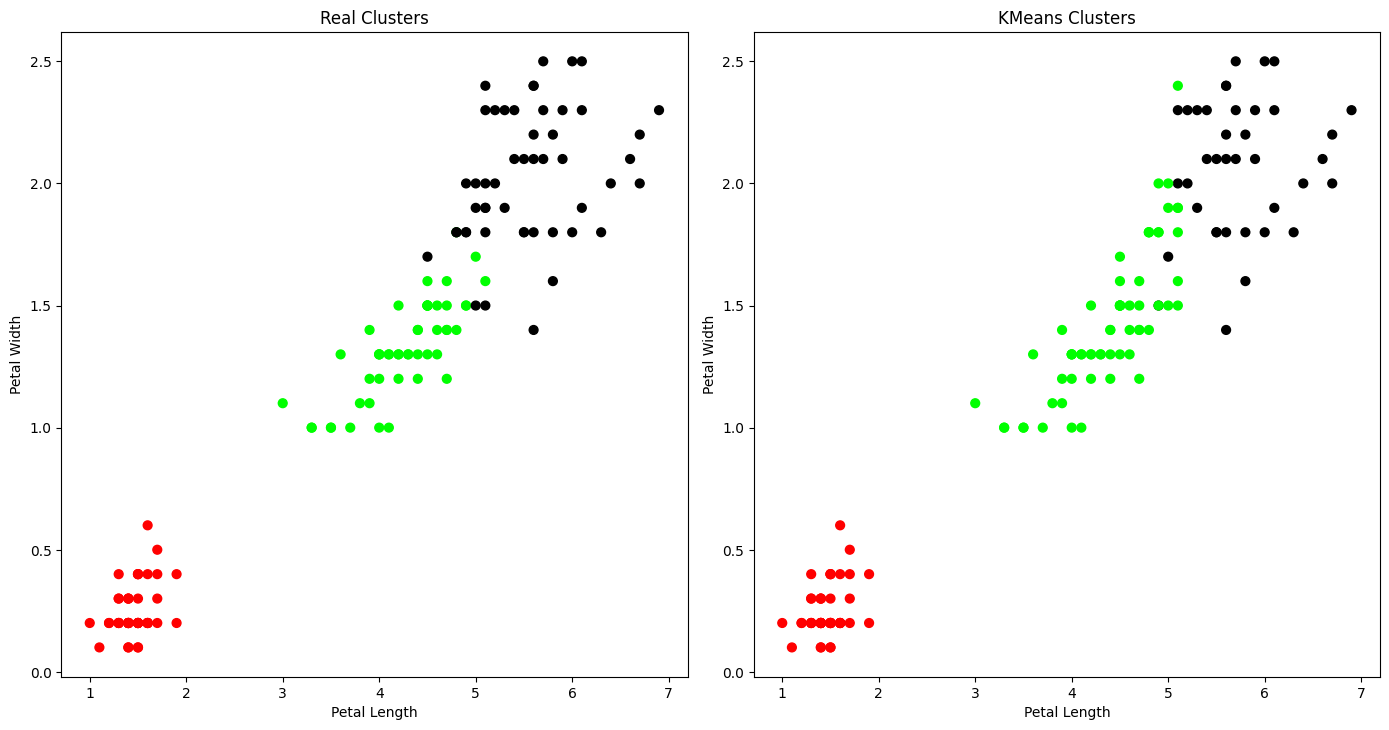

Cluster centers (centroids):
[[5.006      3.428      1.462      0.246     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]
 [6.85       3.07368421 5.74210526 2.07105263]]


In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Load built-in Iris dataset (150 samples, 4 features, 3 species)
iris = datasets.load_iris()

X = pd.DataFrame(iris.data)
X.columns = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']

y = pd.DataFrame(iris.target)
y.columns = ["Targets"]

# Apply K-Means with 3 clusters (matching 3 Iris species)
model = KMeans(n_clusters=3)
model.fit(X)

# Visualize: Real labels vs K-Means labels
plt.figure(figsize=(14, 14))
colormap = np.array(['red', 'lime', 'black'])

plt.subplot(2, 2, 1)
plt.scatter(X.Petal_length, X.Petal_width, c=colormap[y.Targets], s=40)
plt.title("Real Clusters")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.subplot(2, 2, 2)
plt.scatter(X.Petal_length, X.Petal_width, c=colormap[model.labels_], s=40)
plt.title("KMeans Clusters")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.tight_layout()
plt.show()

print("Cluster centers (centroids):")
print(model.cluster_centers_)

In [7]:
import pandas as pd
from kmodes.kmodes import KModes

# Categorical dataset: Color, Shape, Size
data = {
    'Color': ['Red', 'Blue', 'Green', 'Green', 'Blue', 'Red', 'Red', 'Green'],
    'Shape': ['Circle', 'Square', 'Circle', 'Square', 'Circle', 'Circle', 'Square', 'Square'],
    'Size': ['Small', 'Large', 'Large', 'Small', 'Small', 'Large', 'Small', 'Large']
}
df = pd.DataFrame(data)

print("Original dataset")
print(df)

# K-Modes: k=2 clusters, Huang init, 10 random starts
model = KModes(n_clusters=2, init='Huang', n_init=10, verbose=0)
model.fit(df)

cluster_labels = model.labels_
print("\nCluster labels:")
print(cluster_labels)

print("\nCluster Centroids (Modes)")
print(model.cluster_centroids_)

df['Cluster'] = cluster_labels
print('\nDataset with cluster')
print(df)

Original dataset
   Color   Shape   Size
0    Red  Circle  Small
1   Blue  Square  Large
2  Green  Circle  Large
3  Green  Square  Small
4   Blue  Circle  Small
5    Red  Circle  Large
6    Red  Square  Small
7  Green  Square  Large

Cluster labels:
[0 1 1 1 0 0 0 1]

Cluster Centroids (Modes)
[['Red' 'Circle' 'Small']
 ['Green' 'Square' 'Large']]

Dataset with cluster
   Color   Shape   Size  Cluster
0    Red  Circle  Small        0
1   Blue  Square  Large        1
2  Green  Circle  Large        1
3  Green  Square  Small        1
4   Blue  Circle  Small        0
5    Red  Circle  Large        0
6    Red  Square  Small        0
7  Green  Square  Large        1


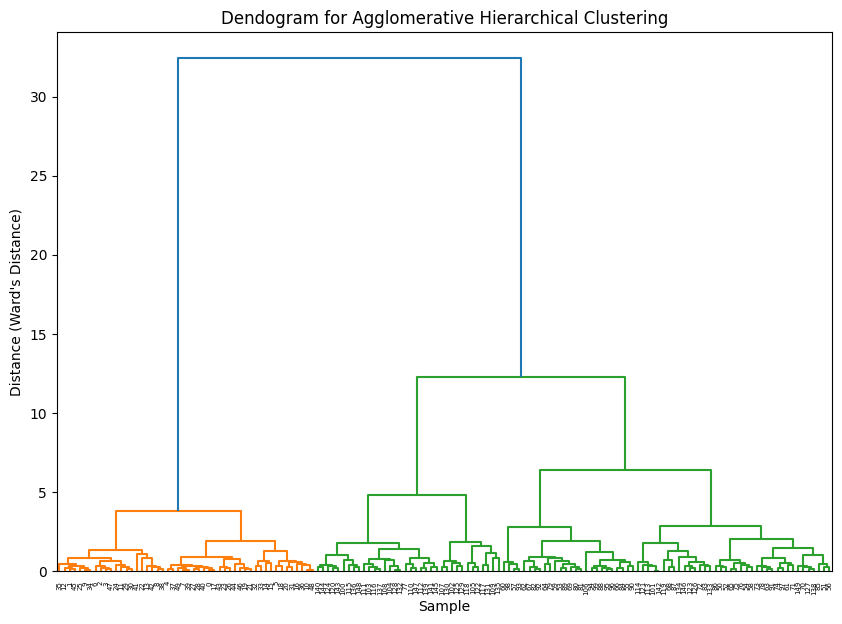

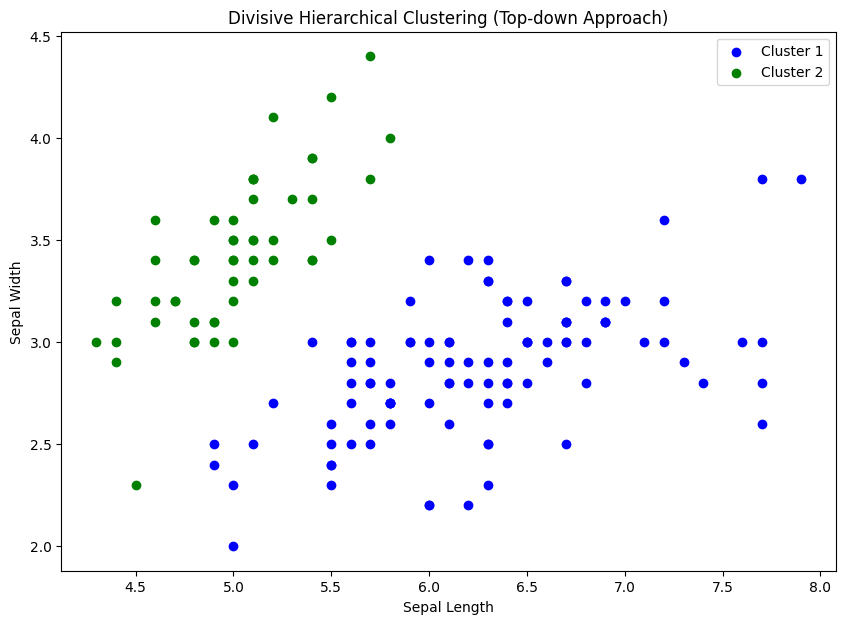

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

iris = datasets.load_iris()
X = iris.data
y = iris.target

# Agglomerative: Ward linkage dendrogram
Z = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendogram for Agglomerative Hierarchical Clustering")
plt.ylabel("Distance (Ward's Distance)")
plt.xlabel("Sample")
plt.show()

def divisive_clustering(X, n_clusters=2):
    """Top-down: recursively split into 2 until n_clusters reached."""
    if n_clusters <= 1:
        return [X]
    model = AgglomerativeClustering(n_clusters=2)
    labels = model.fit_predict(X)
    cluster_1 = X[labels == 0]
    cluster_2 = X[labels == 1]
    result = []
    if len(cluster_1) > 1:
        result += divisive_clustering(cluster_1, n_clusters=n_clusters // 2)
    if len(cluster_2) > 1:
        result += divisive_clustering(cluster_2, n_clusters=n_clusters // 2)
    return result

divisive_result = divisive_clustering(X, n_clusters=2)
plt.figure(figsize=(10, 7))
colors = ['blue', 'green']
for idx, cluster in enumerate(divisive_result):
    plt.scatter(cluster[:, 0], cluster[:, 1], label=f'Cluster {idx + 1}', color=colors[idx % len(colors)])
plt.title("Divisive Hierarchical Clustering (Top-down Approach)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

/var/folders/vp/_fkxj0n10nq0vp5t__2782_c0000gn/T/ipykernel_34449/2003305155.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('rainbow', n_clusters)


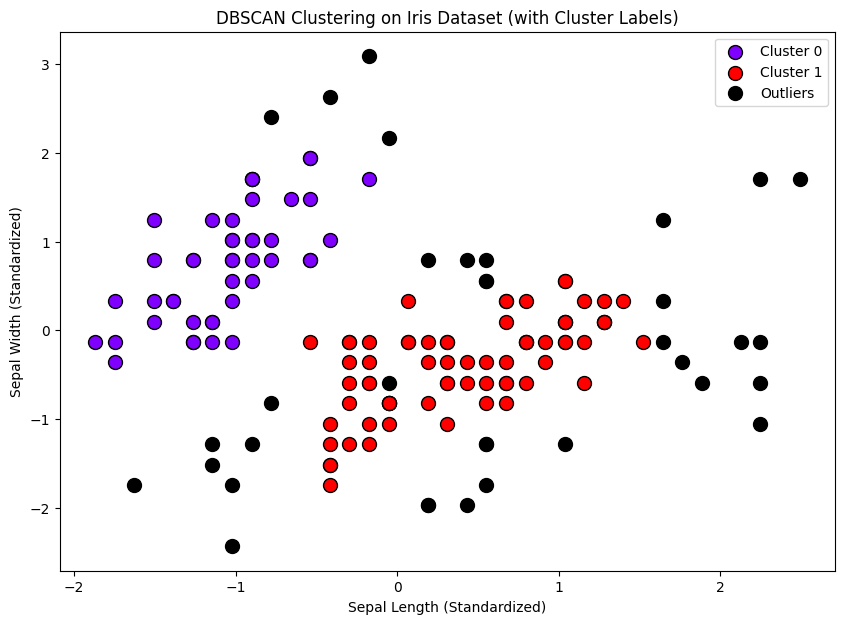

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)
colors = plt.cm.get_cmap('rainbow', n_clusters)

for i, label in enumerate(unique_labels):
    if label == -1:
        color, label_name = 'black', 'Outliers'
    else:
        color, label_name = colors(i), f'Cluster {label}'
    cluster_points = X_scaled[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=color,
                label=label_name, s=100, edgecolor ='k')

plt.title("DBSCAN Clustering on Iris Dataset (with Cluster Labels)")
plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.legend()
plt.show()

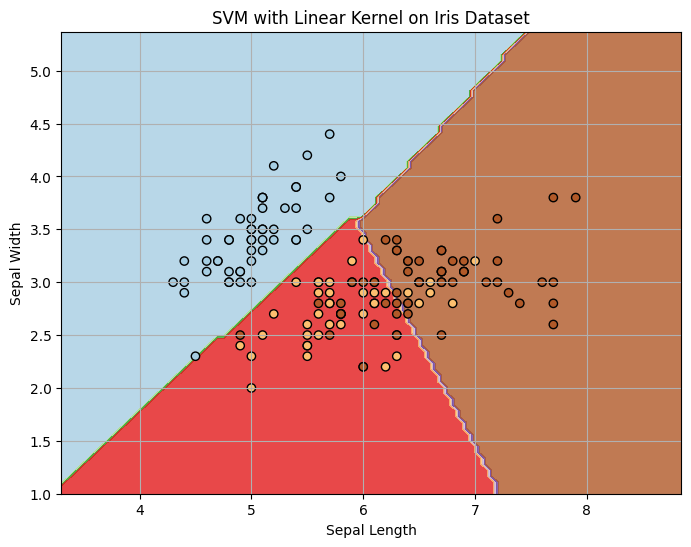

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

iris = datasets.load_iris()
X = iris.data[:, :2]   # Sepal length and width only
y = iris.target

c = 1.0
SVC = svm.SVC(kernel='linear', C=c).fit(X, y)

# Create mesh grid for decision boundary visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = (x_max - x_min) / 100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

z = SVC.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, z, cmap=plt.cm.Paired, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("SVM with Linear Kernel on Iris Dataset")
plt.grid(True)
plt.show()

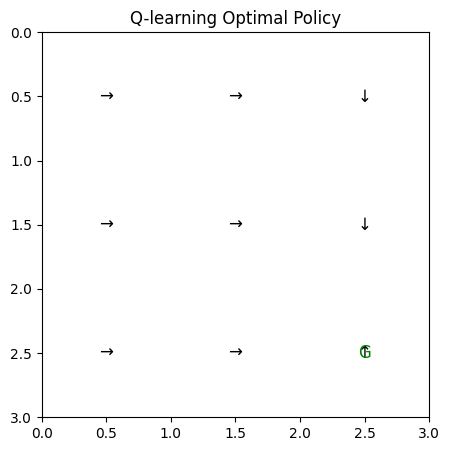

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class Gridworld:
    def __init__(self):
        self.size = (3, 3)
        self.goal = (2, 2)
        self.state = (0, 0)

    def reset(self):
        self.state = (0, 0)
        return self.state

    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        actions = [(0, -1), (1, 0), (0, 1), (-1, 0)]
        next_state = (self.state[0] + actions[action][0],
                      self.state[1] + actions[action][1])
        if 0 <= next_state[0] < 3 and 0 <= next_state[1] < 3:
            self.state = next_state
        return self.state, 0 if self.state == self.goal else -1

env = Gridworld()
q_table = np.zeros((3, 3, 4))  # state_x, state_y, action
alpha, gamma, epsilon = 0.1, 0.9, 0.1
episodes = 1000

for _ in range(episodes):
    state = env.reset()
    done = False
    while not done:
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(4)
        else:
            action = np.argmax(q_table[state[0], state[1]])
        next_state, reward = env.step(action)
        q_table[state[0], state[1], action] = (
            reward + gamma * np.max(q_table[next_state[0], next_state[1]])
        )
        state = next_state
        if state == env.goal:
            done = True

# Visualize optimal policy
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_ylim(3, 0)
ax.set_xlim(0, 3)
actions = ['↑', '→', '↓', '←']
for y in range(3):
    for x in range(3):
        action = np.argmax(q_table[x, y])
        ax.text(x + 0.5, y + 0.5, actions[action], ha='center', va='center', fontsize=12)
ax.text(2.5, 2.5, "G", ha='center', va='center', fontsize=12, color="green")
plt.title("Q-learning Optimal Policy")
plt.show()

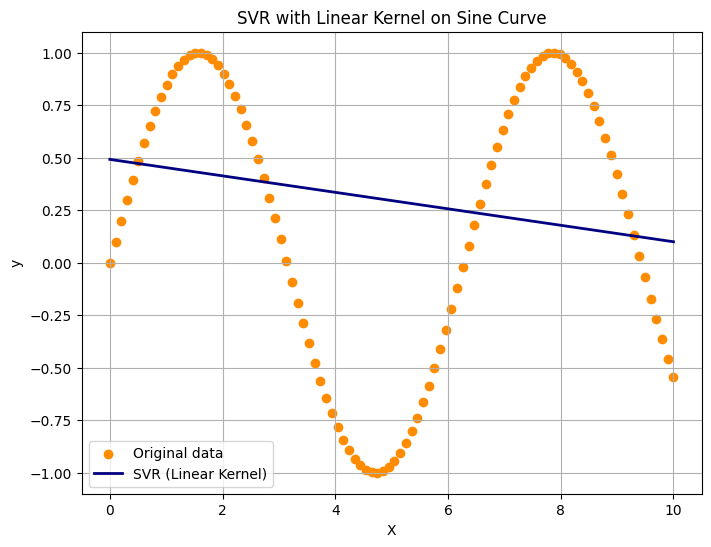

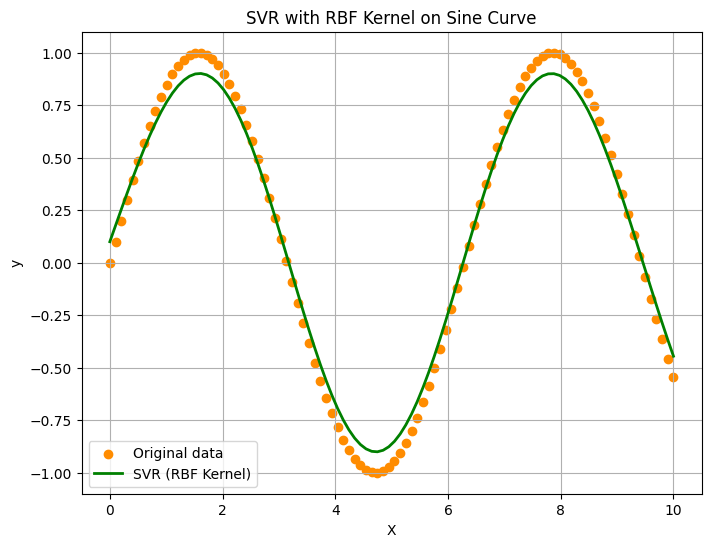

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

X = np.linspace(0, 10, 100)
y = np.sin(X)
X = X.reshape(-1, 1)  # sklearn expects 2D input

svr_linear = SVR(kernel="linear", C=1000, gamma='scale', epsilon=0.1)
svr_rbf = SVR(kernel="rbf", C=1000, gamma='scale', epsilon=0.1)
svr_linear.fit(X, y)
svr_rbf.fit(X, y)
y_pred_linear = svr_linear.predict(X)
y_pred_rbf = svr_rbf.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="darkorange", label="Original data")
plt.plot(X, y_pred_linear, color="navy", lw=2, label="SVR (Linear Kernel)")
plt.title("SVR with Linear Kernel on Sine Curve")
plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="darkorange", label="Original data")
plt.plot(X, y_pred_rbf, color="green", lw=2, label="SVR (RBF Kernel)")
plt.title("SVR with RBF Kernel on Sine Curve")
plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.grid(True)
plt.show()  # Note: original code has typo Plt.show()

Generation 1 - Best Fitness: 23.79856849910033
Generation 2 - Best Fitness: 23.79856849910033
Generation 3 - Best Fitness: 25.0
Generation 100 - Best Fitness: 25.0
Best solution: -5.0
Best fitness (f(x) = x^2): 25.0


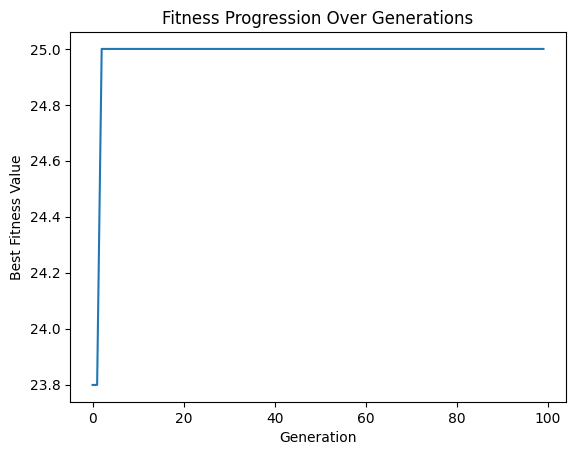

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt

def fitness(x):
    return x ** 2

def initialize_population(pop_size, lower, upper):
    return np.random.uniform(lower, upper, pop_size)

def select_parents(population, fitness_values):
    parents = []
    for _ in range(len(population) // 2):
        tournament = random.sample(list(zip(population, fitness_values)), 3)
        parents.append(max(tournament, key=lambda x: x[1])[0])
    return np.array(parents)

def crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            child = (parents[i] + parents[i + 1]) / 2
            offspring.append(child)
    return np.array(offspring)

def mutate(population, mutation_rate, lower, upper):
    for i in range(len(population)):
        if random.random() < mutation_rate:
            population[i] += np.random.uniform(-0.5, 0.5)
            population[i] = np.clip(population[i], lower, upper)
    return population

def genetic_algorithm(pop_size, generations, lower, upper, mutation_rate):
    population = initialize_population(pop_size, lower, upper)
    fitness_history = []
    for generation in range(generations):
        fitness_values = np.array([fitness(x) for x in population])
        best_fitness = np.max(fitness_values)
        fitness_history.append(best_fitness)
        if generation < 3 or generation == 99:
            print(f"Generation {generation + 1} - Best Fitness: {best_fitness}")
        parents = select_parents(population, fitness_values)
        offspring = crossover(parents)
        while len(offspring) < len(population):
            offspring = np.append(offspring, parents[random.randint(0, len(parents) - 1)])
        population = mutate(offspring, mutation_rate, lower, upper)
    best_solution = population[np.argmax([fitness(x) for x in population])]
    return best_solution, fitness_history

best_solution, fitness_history = genetic_algorithm(20, 100, -5, 5, 0.1)
print(f"Best solution: {best_solution}")
print(f"Best fitness (f(x) = x^2): {fitness(best_solution)}")
plt.plot(fitness_history)
plt.xlabel('Generation'); plt.ylabel('Best Fitness Value')
plt.title('Fitness Progression Over Generations')
plt.show()

In [14]:
import numpy as np

dataset = [
    {"Age": 22, "Income": 30000, "Buy Product": "No"},
    {"Age": 25, "Income": 50000, "Buy Product": "Yes"},
    {"Age": 45, "Income": 80000, "Buy Product": "Yes"},
    {"Age": 35, "Income": 40000, "Buy Product": "No"},
]

def satisfies_condition(example, condition):
    return condition(example)

def ebl(dataset):
    explanation = None
    for example in dataset:
        if example["Buy Product"] == "Yes":
            explanation = lambda x: (25 <= x["Age"] <= 45) and (x["Income"] > 40000)
            break
    return explanation

def test_explanation(dataset, explanation):
    tp = fp = tn = fn = 0
    predictions = []
    for example in dataset:
        predicted = "Yes" if satisfies_condition(example, explanation) else "No"
        predictions.append(predicted)
        if predicted == example["Buy Product"]:
            if predicted == "Yes": tp += 1
            else: tn += 1
        else:
            if predicted == "Yes": fp += 1
            else: fn += 1
    accuracy = correct = tp + tn
    accuracy = accuracy / len(dataset) * 100
    return accuracy, predictions, tp, fp, tn, fn

def run():
    explanation = ebl(dataset)
    print("Learned Rule: If age 25-45 and income > 40000, they will buy.")
    accuracy, predictions, tp, fp, tn, fn = test_explanation(dataset, explanation)
    print(f"Explanation-based learning accuracy: {accuracy}%")
    for i, example in enumerate(dataset):
        print(f"Example {i+1}: Predicted = {predictions[i]}, Actual = {example['Buy Product']}")
    print(f"True Positives: {tp}, False Positives: {fp}")
    print(f"True Negatives: {tn}, False Negatives: {fn}")

run()

Learned Rule: If age 25-45 and income > 40000, they will buy.
Explanation-based learning accuracy: 100.0%
Example 1: Predicted = No, Actual = No
Example 2: Predicted = Yes, Actual = Yes
Example 3: Predicted = Yes, Actual = Yes
Example 4: Predicted = No, Actual = No
True Positives: 2, False Positives: 0
True Negatives: 2, False Negatives: 0
